# Práctica: Comparación de Modelos de Regresión Demográfica (RL, RP, RF)

**Materia:** Tópicos de Big Data  
**Tema:** Modelos de regresión supervisados aplicados a series demográficas de Our World in Data (OWID)  
**Herramientas:** Python · Pandas · NumPy · Matplotlib · Scikit-learn (Regresión Lineal, Regresión Polinomial, Random Forest)

---

### Ejercicios a realizar:
1. **Ejercicio 1: Extraer el país de China**
   - Modelos de regresión para Nacimientos (Regresión Lineal, Regresión Polinomial grado 2, Random Forest)
   - Modelos de regresión para Defunciones (Regresión Lineal, Regresión Polinomial grado 2, Random Forest)
   - Proyecciones hacia el año 2100 y comparación visual con las estimaciones de OWID / ONU.
2. **Ejercicio 2: Extraer nacimientos / defunciones a partir del año 2000 en México**
   - Filtrado de la serie histórica mexicana en el periodo 2000 – 2023.
   - Modelos de regresión para Nacimientos (RL, RP, RF)
   - Modelos de regresión para Defunciones (RL, RP, RF)
   - Proyecciones hacia el año 2100 y comparación visual con las estimaciones de OWID / ONU.


## 1. Importación de bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor


## 2. Carga y preparación del dataset

In [2]:
# Carga de datos desde archivo local o URL remota de Our World in Data
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"
posibles_rutas = [
    "births-and-deaths-projected-to-2100.csv",
    "../births-and-deaths-projected-to-2100.csv",
    "U3_1_modelos_ml/births-and-deaths-projected-to-2100.csv"
]

archivo_local = next((p for p in posibles_rutas if os.path.exists(p)), None)

if archivo_local:
    print(f"Cargando dataset local: {archivo_local}")
    df = pd.read_csv(archivo_local)
else:
    print("Descargando dataset desde Our World in Data...")
    df = pd.read_csv(url, storage_options={"User-Agent": "Our World In Data data fetch/1.0"})

# Renombrar columnas para simplificar su uso
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

# Unificar datos históricos y proyecciones en columnas births y deaths
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

# Definir vector de años futuros (2024 - 2100) para proyecciones
anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

df.head()


Cargando dataset local: ../births-and-deaths-projected-to-2100.csv


,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0



# EJERCICIO 1: Extraer el país de China



In [3]:
# Filtrar datos correspondientes a China
pais = "China"
df_china = df[df["Entity"] == pais].copy()

# Separación de datos históricos (1950 - 2023) y proyecciones oficiales (2024 - 2100)
df_china_historico = df_china[df_china["Year"] <= 2023].copy()
df_china_proyectado = df_china[df_china["Year"] > 2023].copy()

print("China - Histórico  ->", df_china_historico.shape, "| Rango de años:", df_china_historico["Year"].min(), "a", df_china_historico["Year"].max())
print("China - Proyectado ->", df_china_proyectado.shape, "| Rango de años:", df_china_proyectado["Year"].min(), "a", df_china_proyectado["Year"].max())


China - Histórico  -> (74, 9) | Rango de años: 1950 a 2023
China - Proyectado -> (77, 9) | Rango de años: 2024 a 2100


### 1.1 Exploración gráfica de datos en China

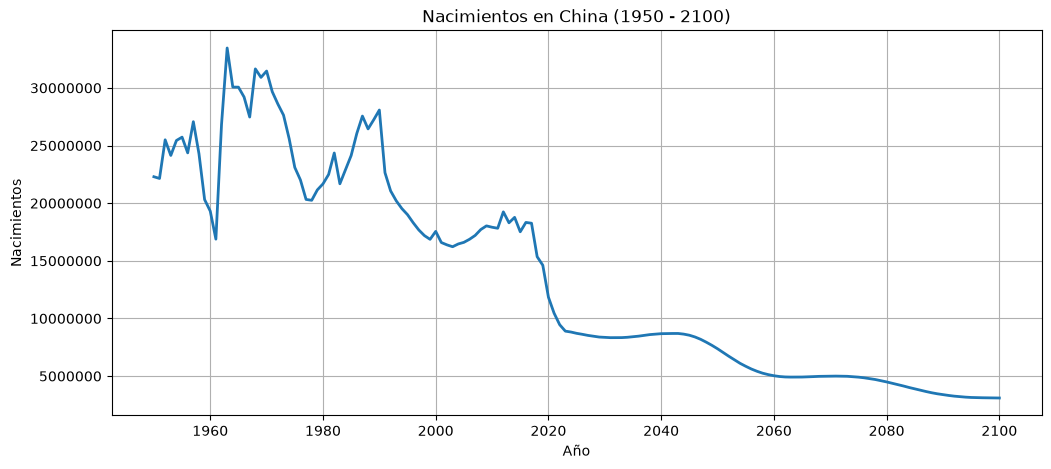

In [4]:
# Gráfica histórica de nacimientos en China
plt.figure(figsize=(12, 5))
plt.plot(df_china["Year"], df_china["births"], color="tab:blue", linewidth=2)
plt.title("Nacimientos en China (1950 - 2100)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(True)
plt.show()


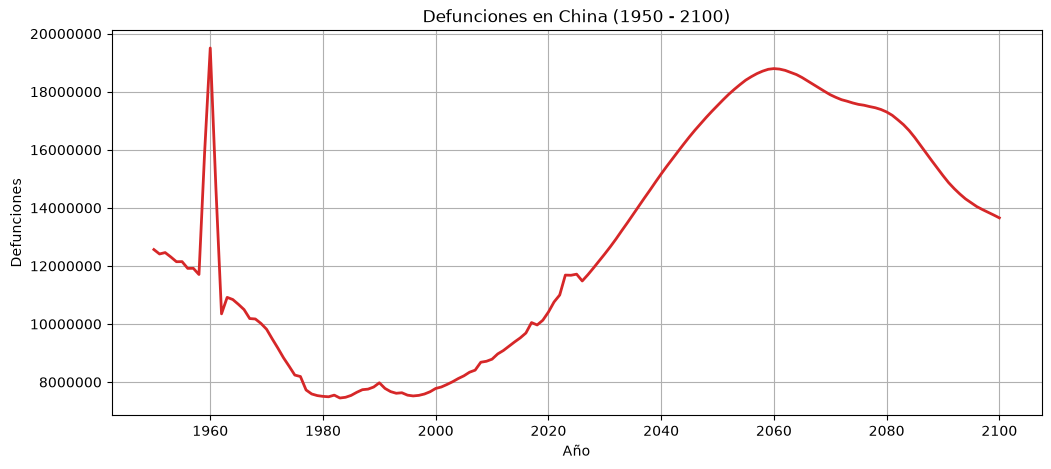

In [5]:
# Gráfica histórica de defunciones en China
plt.figure(figsize=(12, 5))
plt.plot(df_china["Year"], df_china["deaths"], color="tab:red", linewidth=2)
plt.title("Defunciones en China (1950 - 2100)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(True)
plt.show()


### 1.2 Modelos para Nacimientos en China (RL, RP, RF)

In [6]:
# Preparación de variables de entrada y salida
X_china = df_china_historico[["Year"]]
y_china_births = df_china_historico["births"]

# Transformador polinomial de grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_china_poly = poly.fit_transform(X_china)
X_futuro_poly = poly.transform(X_futuro)


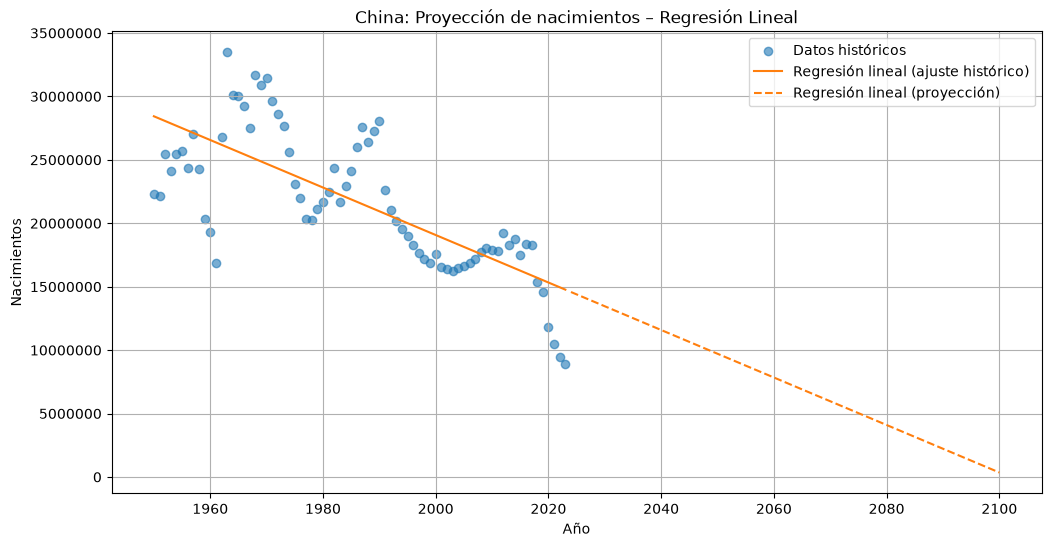

In [7]:
# 1. Regresión Lineal - Nacimientos China
lr_china_births = LinearRegression()
lr_china_births.fit(X_china, y_china_births)

pred_lr_china_b_hist = lr_china_births.predict(X_china)
pred_lr_china_b_fut = lr_china_births.predict(X_futuro)

plt.figure(figsize=(12, 6))
plt.scatter(df_china_historico["Year"], df_china_historico["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_china_historico["Year"], pred_lr_china_b_hist, color="tab:orange", label="Regresión lineal (ajuste histórico)")
plt.plot(anios_futuros.flatten(), pred_lr_china_b_fut, color="tab:orange", linestyle="--", label="Regresión lineal (proyección)")
plt.title("China: Proyección de nacimientos – Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


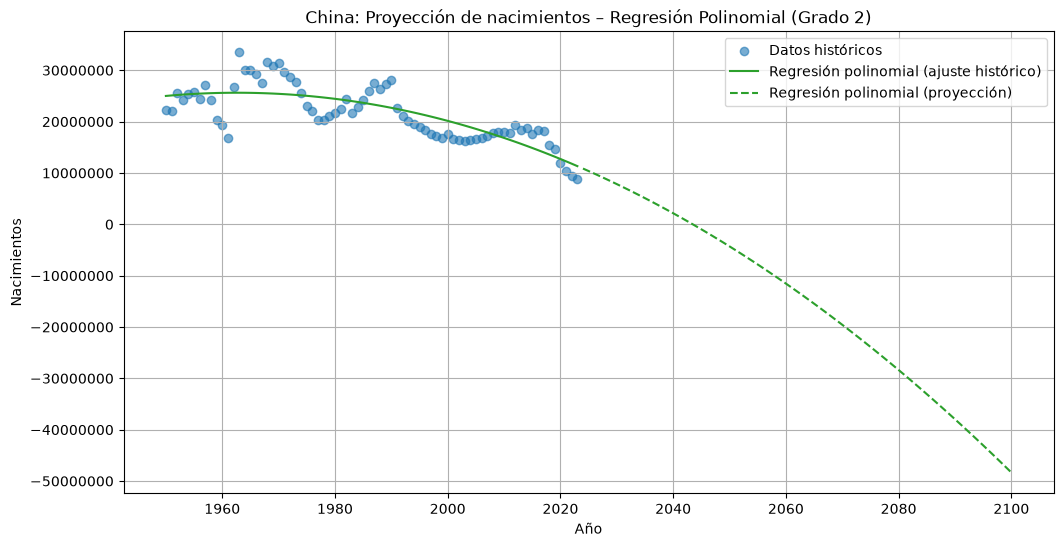

In [8]:
# 2. Regresión Polinomial (Grado 2) - Nacimientos China
pr_china_births = LinearRegression()
pr_china_births.fit(X_china_poly, y_china_births)

pred_pr_china_b_hist = pr_china_births.predict(X_china_poly)
pred_pr_china_b_fut = pr_china_births.predict(X_futuro_poly)

plt.figure(figsize=(12, 6))
plt.scatter(df_china_historico["Year"], df_china_historico["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_china_historico["Year"], pred_pr_china_b_hist, color="tab:green", label="Regresión polinomial (ajuste histórico)")
plt.plot(anios_futuros.flatten(), pred_pr_china_b_fut, color="tab:green", linestyle="--", label="Regresión polinomial (proyección)")
plt.title("China: Proyección de nacimientos – Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


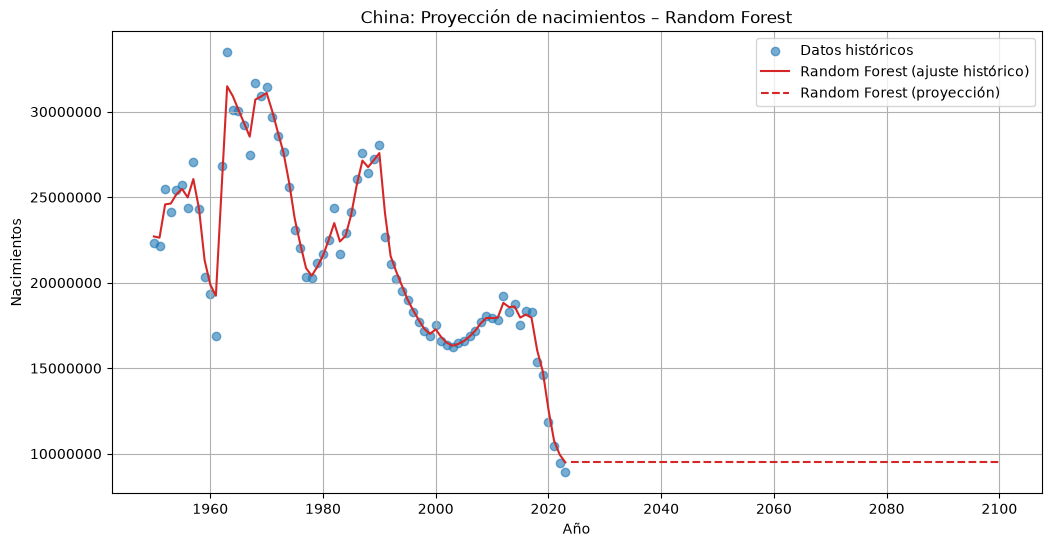

In [9]:
# 3. Random Forest Regressor - Nacimientos China
rf_china_births = RandomForestRegressor(n_estimators=100, random_state=42)
rf_china_births.fit(X_china, y_china_births)

pred_rf_china_b_hist = rf_china_births.predict(X_china)
pred_rf_china_b_fut = rf_china_births.predict(X_futuro)

plt.figure(figsize=(12, 6))
plt.scatter(df_china_historico["Year"], df_china_historico["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_china_historico["Year"], pred_rf_china_b_hist, color="tab:red", label="Random Forest (ajuste histórico)")
plt.plot(anios_futuros.flatten(), pred_rf_china_b_fut, color="tab:red", linestyle="--", label="Random Forest (proyección)")
plt.title("China: Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


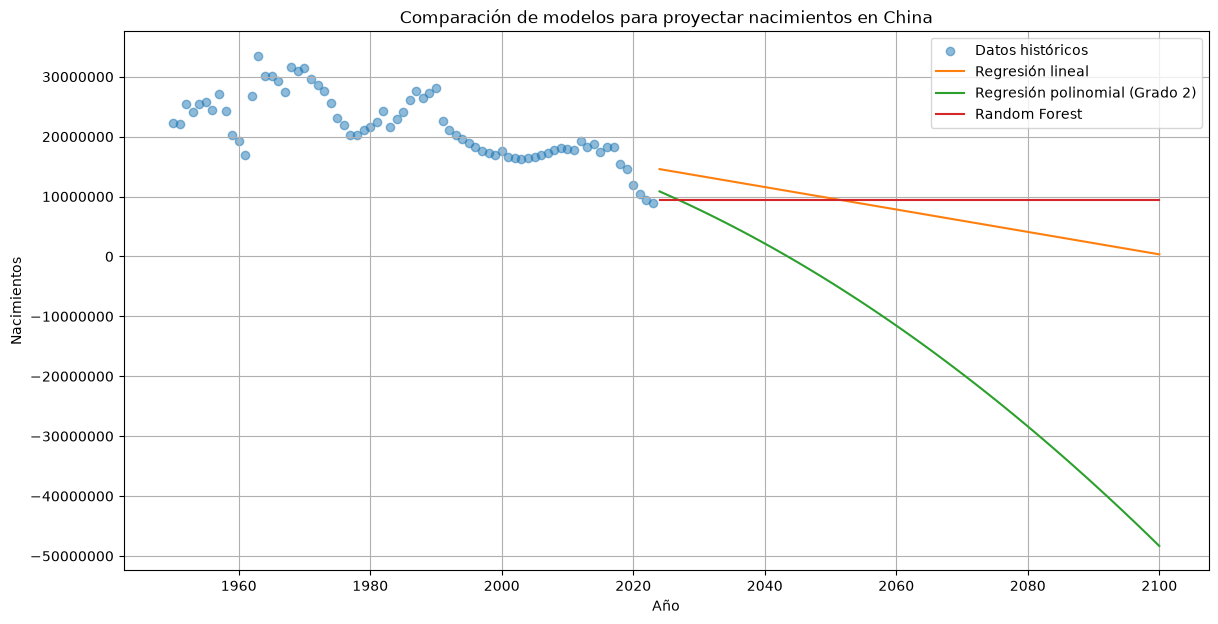

In [10]:
# Comparación conjunta de los tres modelos para Nacimientos en China
plt.figure(figsize=(14, 7))
plt.scatter(df_china_historico["Year"], df_china_historico["births"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros.flatten(), pred_lr_china_b_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_china_b_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_china_b_fut, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar nacimientos en China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


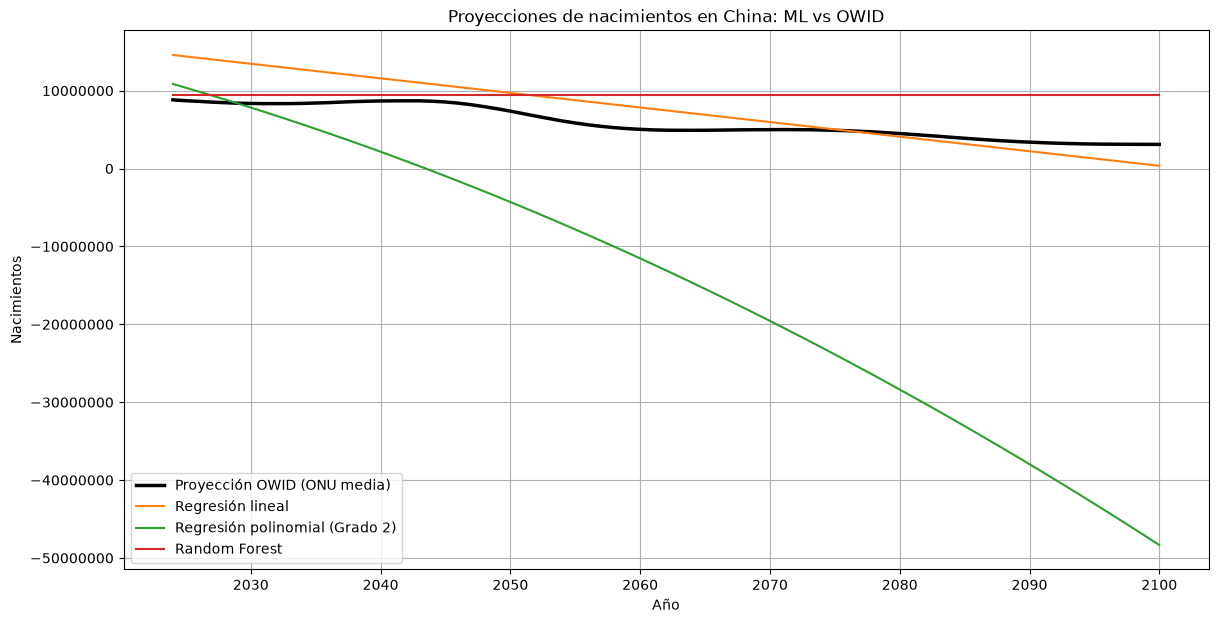

In [11]:
# Comparación de modelos con proyecciones de Our World in Data (Nacimientos China)
plt.figure(figsize=(14, 7))
plt.plot(df_china_proyectado["Year"], df_china_proyectado["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU media)")
plt.plot(anios_futuros.flatten(), pred_lr_china_b_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_china_b_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_china_b_fut, color="tab:red", label="Random Forest")
plt.title("Proyecciones de nacimientos en China: ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


### 1.3 Modelos para Defunciones en China (RL, RP, RF)

In [12]:
y_china_deaths = df_china_historico["deaths"]

# 1. Regresión Lineal
lr_china_deaths = LinearRegression().fit(X_china, y_china_deaths)
pred_lr_china_d_hist = lr_china_deaths.predict(X_china)
pred_lr_china_d_fut = lr_china_deaths.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
pr_china_deaths = LinearRegression().fit(X_china_poly, y_china_deaths)
pred_pr_china_d_hist = pr_china_deaths.predict(X_china_poly)
pred_pr_china_d_fut = pr_china_deaths.predict(X_futuro_poly)

# 3. Random Forest Regressor
rf_china_deaths = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_china, y_china_deaths)
pred_rf_china_d_hist = rf_china_deaths.predict(X_china)
pred_rf_china_d_fut = rf_china_deaths.predict(X_futuro)


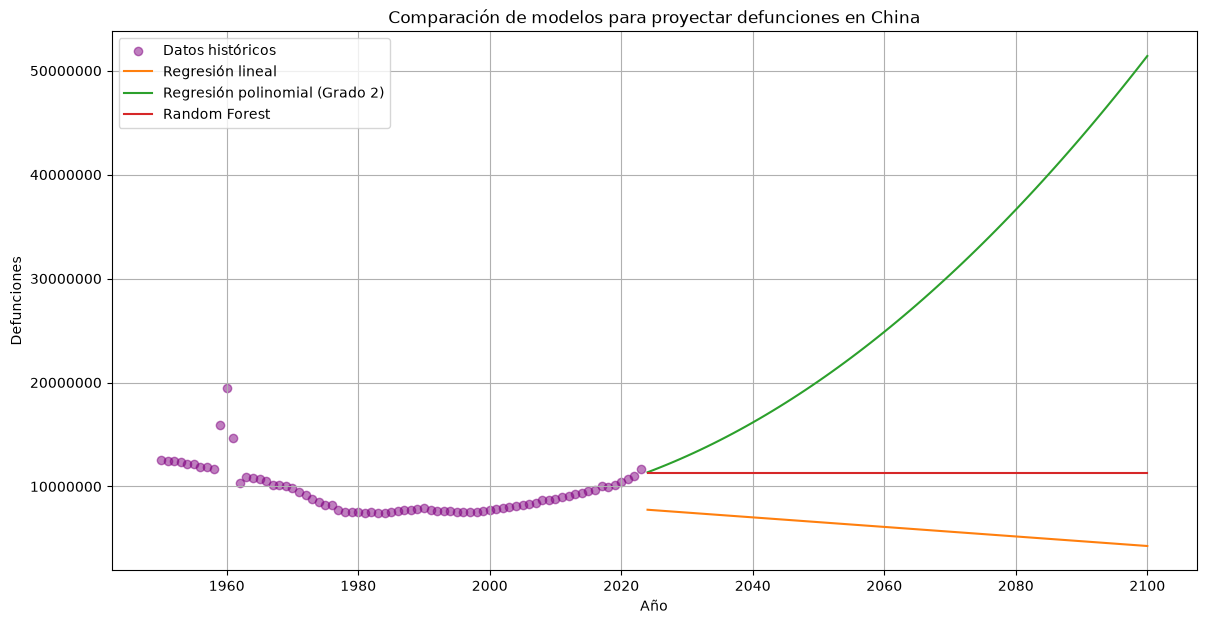

In [13]:
# Comparación conjunta de los tres modelos para Defunciones en China
plt.figure(figsize=(14, 7))
plt.scatter(df_china_historico["Year"], df_china_historico["deaths"], label="Datos históricos", alpha=0.5, color="purple")
plt.plot(anios_futuros.flatten(), pred_lr_china_d_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_china_d_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_china_d_fut, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar defunciones en China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


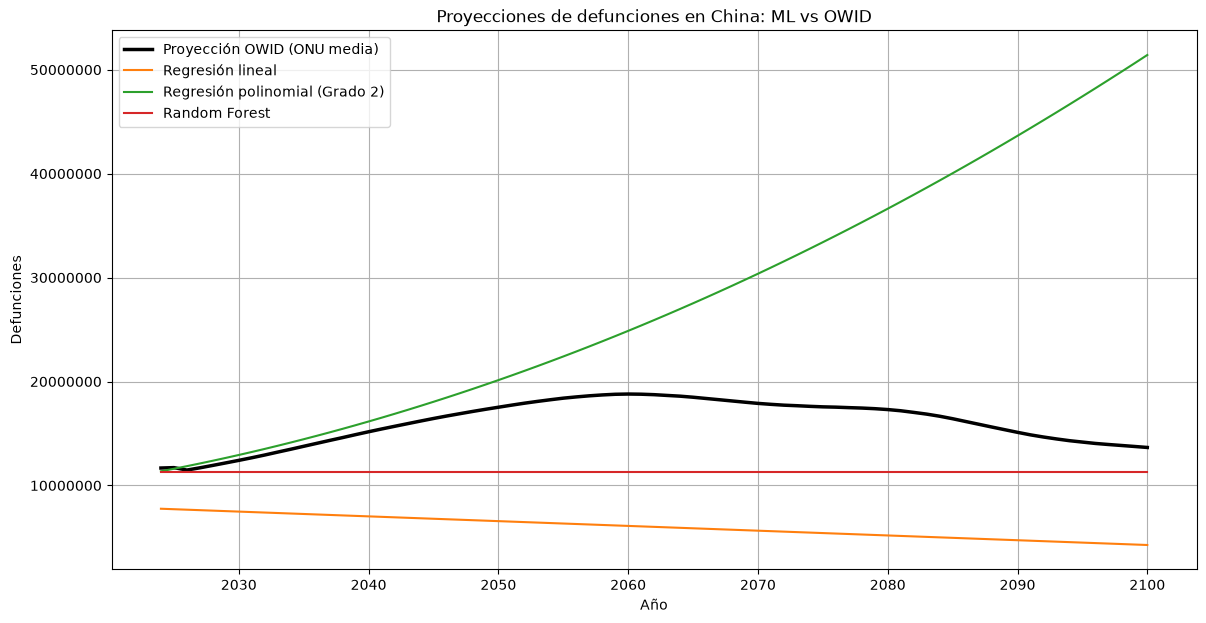

In [14]:
# Comparación de modelos con proyecciones de Our World in Data (Defunciones China)
plt.figure(figsize=(14, 7))
plt.plot(df_china_proyectado["Year"], df_china_proyectado["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU media)")
plt.plot(anios_futuros.flatten(), pred_lr_china_d_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_china_d_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_china_d_fut, color="tab:red", label="Random Forest")
plt.title("Proyecciones de defunciones en China: ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


### 1.4 Resumen numérico de proyecciones para China

In [15]:
anios_tabla = [2030, 2050, 2075, 2100]
indice = anios_futuros.flatten()

def construir_tabla_resumen(df_proy, col, lineal, polinomial, rf):
    tabla = pd.DataFrame({
        "OWID (ONU)": df_proy.set_index("Year")[col].reindex(indice).to_numpy(),
        "Regresión Lineal": lineal,
        "Regresión Polinomial": polinomial,
        "Random Forest": rf
    }, index=indice)
    tabla.index.name = "Año"
    return tabla.loc[anios_tabla]

print("CHINA - Proyección de Nacimientos:")
display(construir_tabla_resumen(df_china_proyectado, "births", pred_lr_china_b_fut, pred_pr_china_b_fut, pred_rf_china_b_fut).style.format("{:,.0f}"))

print("\nCHINA - Proyección de Defunciones:")
display(construir_tabla_resumen(df_china_proyectado, "deaths", pred_lr_china_d_fut, pred_pr_china_d_fut, pred_rf_china_d_fut).style.format("{:,.0f}"))


CHINA - Proyección de Nacimientos:


,OWID (ONU),Regresión Lineal,Regresión Polinomial,Random Forest
Año,,,,
2030,"8,359,513","13,456,651","7,830,199","9,489,420"
2050,"7,371,348","9,712,484","-4,298,790","9,489,420"
2075,"4,909,046","5,032,277","-23,867,936","9,489,420"
2100,"3,099,844","352,069","-48,334,758","9,489,420"



CHINA - Proyección de Defunciones:


,OWID (ONU),Regresión Lineal,Regresión Polinomial,Random Forest
Año,,,,
2030,"12,415,078","7,485,699","12,933,834","11,339,159"
2050,"17,526,300","6,567,577","20,134,799","11,339,159"
2075,"17,564,112","5,419,925","33,404,217","11,339,159"
2100,"13,655,445","4,272,272","51,416,093","11,339,159"



# EJERCICIO 2: Extraer nacimientos / defunciones a partir de 2000 en México



In [16]:
# Filtrar datos de México a partir del año 2000
pais_mex = "Mexico"
df_mexico = df[df["Entity"] == pais_mex].copy()

# Datos históricos restringidos a partir del año 2000 (2000 a 2023)
df_mexico_historico = df_mexico[(df_mexico["Year"] >= 2000) & (df_mexico["Year"] <= 2023)].copy()

# Proyecciones oficiales de OWID (2024 a 2100)
df_mexico_proyectado = df_mexico[df_mexico["Year"] > 2023].copy()

print("México - Histórico (>= 2000) ->", df_mexico_historico.shape, "| Rango de años:", df_mexico_historico["Year"].min(), "a", df_mexico_historico["Year"].max())
print("México - Proyectado          ->", df_mexico_proyectado.shape, "| Rango de años:", df_mexico_proyectado["Year"].min(), "a", df_mexico_proyectado["Year"].max())


México - Histórico (>= 2000) -> (24, 9) | Rango de años: 2000 a 2023
México - Proyectado          -> (77, 9) | Rango de años: 2024 a 2100


### 2.1 Exploración gráfica de datos en México (2000 - 2023)

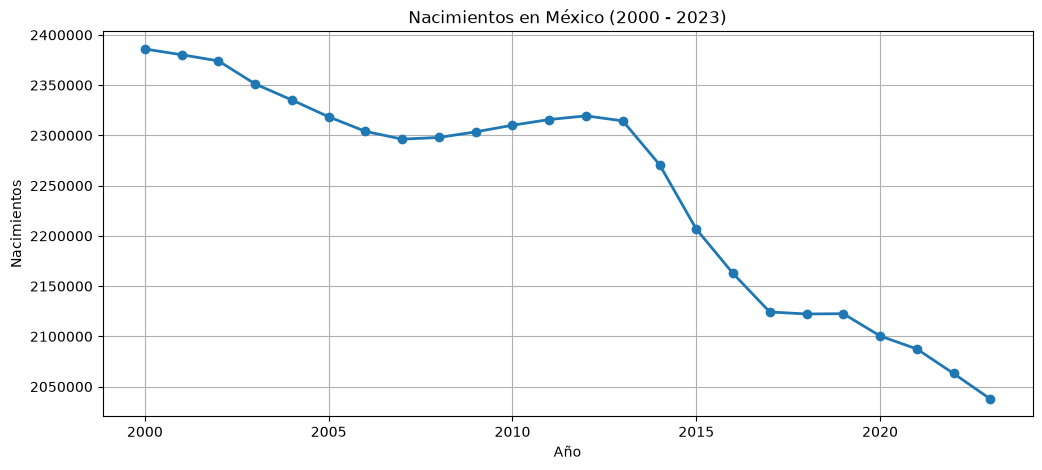

In [17]:
# Gráfica histórica de nacimientos en México (2000-2023)
plt.figure(figsize=(12, 5))
plt.plot(df_mexico_historico["Year"], df_mexico_historico["births"], marker="o", color="tab:blue", linewidth=2)
plt.title("Nacimientos en México (2000 - 2023)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(True)
plt.show()


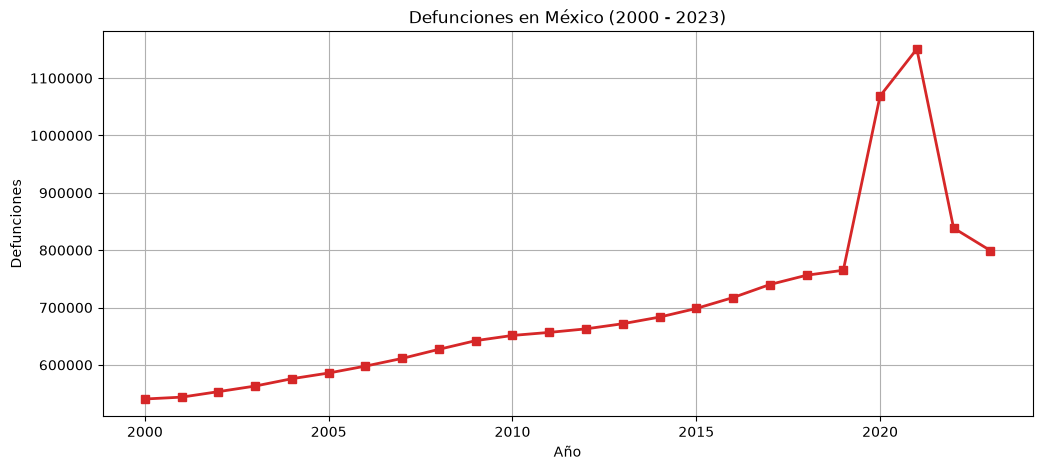

In [18]:
# Gráfica histórica de defunciones en México (2000-2023)
plt.figure(figsize=(12, 5))
plt.plot(df_mexico_historico["Year"], df_mexico_historico["deaths"], marker="s", color="tab:red", linewidth=2)
plt.title("Defunciones en México (2000 - 2023)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(True)
plt.show()


### 2.2 Modelos para Nacimientos en México a partir de 2000 (RL, RP, RF)

In [19]:
# Variables de entrenamiento para México
X_mex = df_mexico_historico[["Year"]]
y_mex_births = df_mexico_historico["births"]

# Transformación polinomial de grado 2
X_mex_poly = poly.fit_transform(X_mex)
X_mex_futuro_poly = poly.transform(X_futuro)


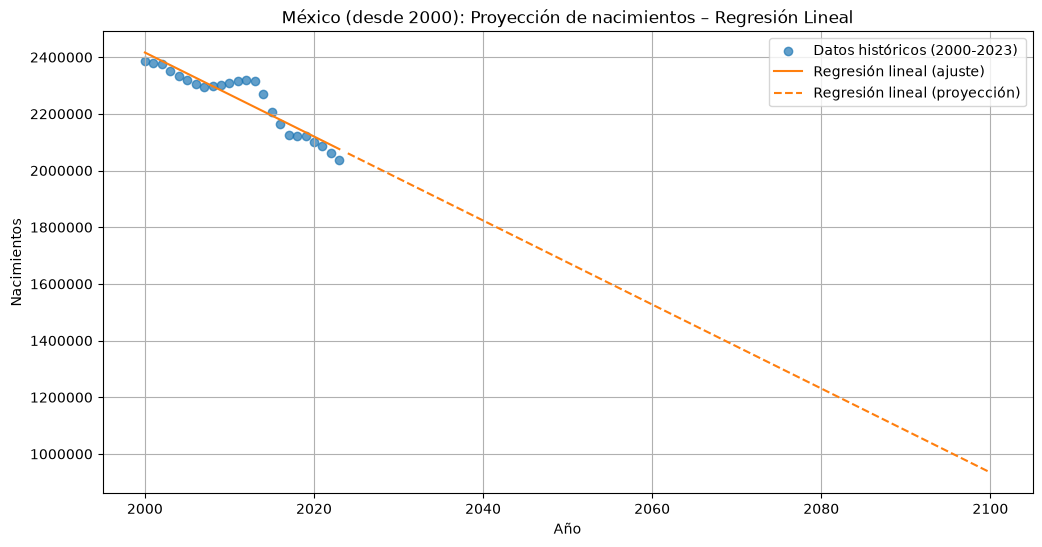

In [20]:
# 1. Regresión Lineal - Nacimientos México (desde 2000)
lr_mex_births = LinearRegression()
lr_mex_births.fit(X_mex, y_mex_births)

pred_lr_mex_b_hist = lr_mex_births.predict(X_mex)
pred_lr_mex_b_fut = lr_mex_births.predict(X_futuro)

plt.figure(figsize=(12, 6))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.7)
plt.plot(df_mexico_historico["Year"], pred_lr_mex_b_hist, color="tab:orange", label="Regresión lineal (ajuste)")
plt.plot(anios_futuros.flatten(), pred_lr_mex_b_fut, color="tab:orange", linestyle="--", label="Regresión lineal (proyección)")
plt.title("México (desde 2000): Proyección de nacimientos – Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


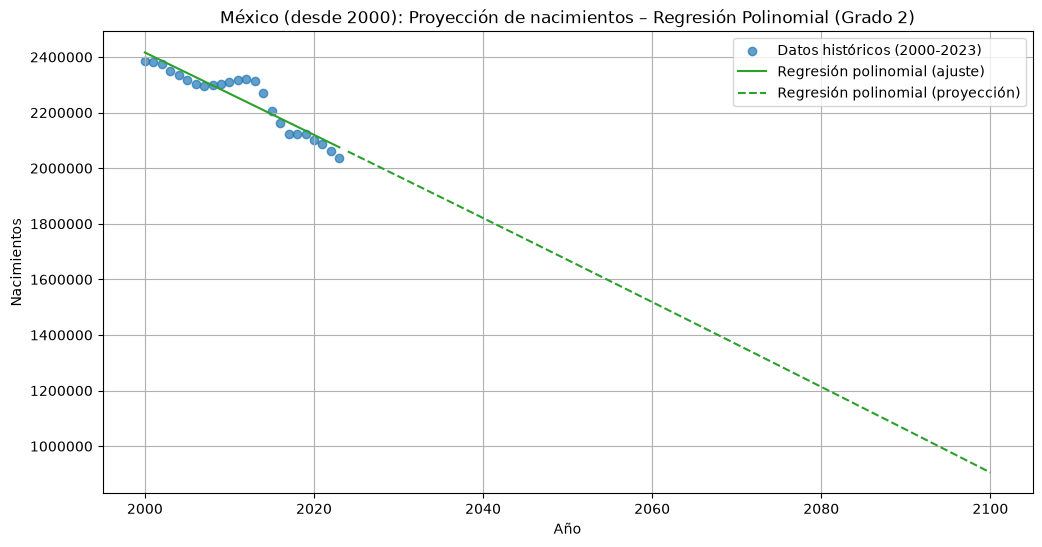

In [21]:
# 2. Regresión Polinomial (Grado 2) - Nacimientos México (desde 2000)
pr_mex_births = LinearRegression()
pr_mex_births.fit(X_mex_poly, y_mex_births)

pred_pr_mex_b_hist = pr_mex_births.predict(X_mex_poly)
pred_pr_mex_b_fut = pr_mex_births.predict(X_mex_futuro_poly)

plt.figure(figsize=(12, 6))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.7)
plt.plot(df_mexico_historico["Year"], pred_pr_mex_b_hist, color="tab:green", label="Regresión polinomial (ajuste)")
plt.plot(anios_futuros.flatten(), pred_pr_mex_b_fut, color="tab:green", linestyle="--", label="Regresión polinomial (proyección)")
plt.title("México (desde 2000): Proyección de nacimientos – Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


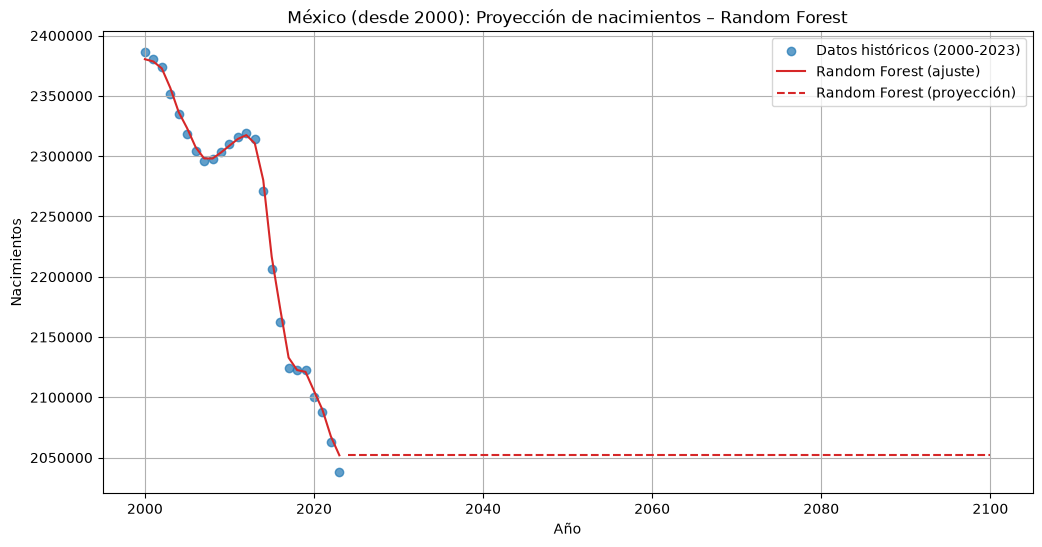

In [22]:
# 3. Random Forest Regressor - Nacimientos México (desde 2000)
rf_mex_births = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mex_births.fit(X_mex, y_mex_births)

pred_rf_mex_b_hist = rf_mex_births.predict(X_mex)
pred_rf_mex_b_fut = rf_mex_births.predict(X_futuro)

plt.figure(figsize=(12, 6))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.7)
plt.plot(df_mexico_historico["Year"], pred_rf_mex_b_hist, color="tab:red", label="Random Forest (ajuste)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_b_fut, color="tab:red", linestyle="--", label="Random Forest (proyección)")
plt.title("México (desde 2000): Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


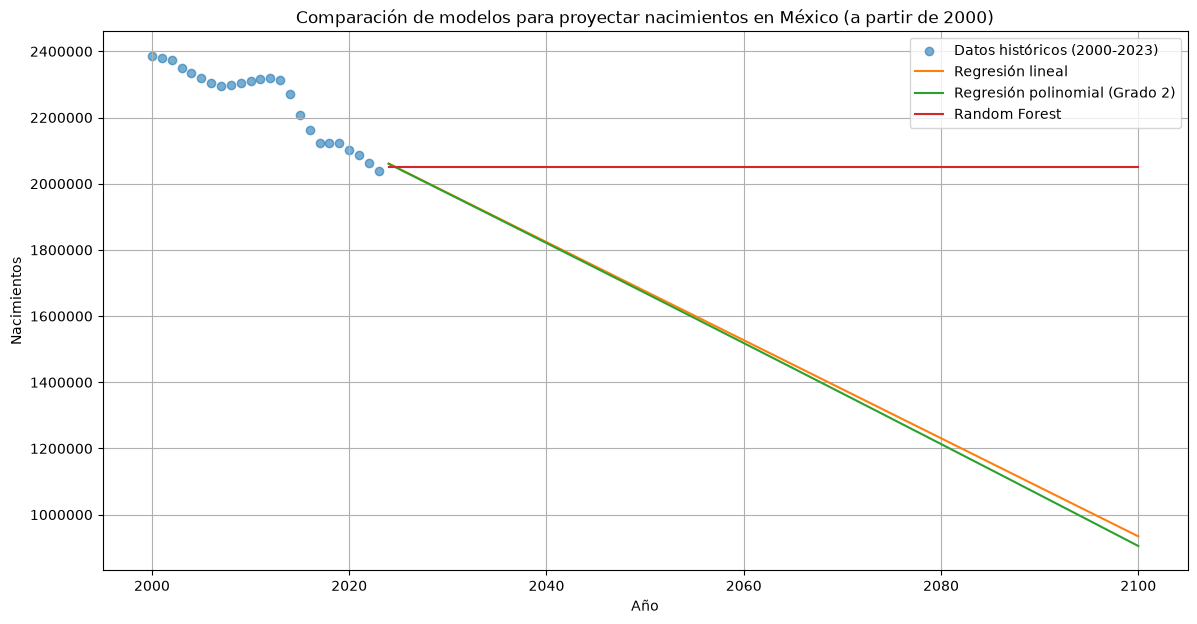

In [23]:
# Comparación conjunta de los tres modelos para Nacimientos en México (desde 2000)
plt.figure(figsize=(14, 7))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.6)
plt.plot(anios_futuros.flatten(), pred_lr_mex_b_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_b_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_b_fut, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar nacimientos en México (a partir de 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


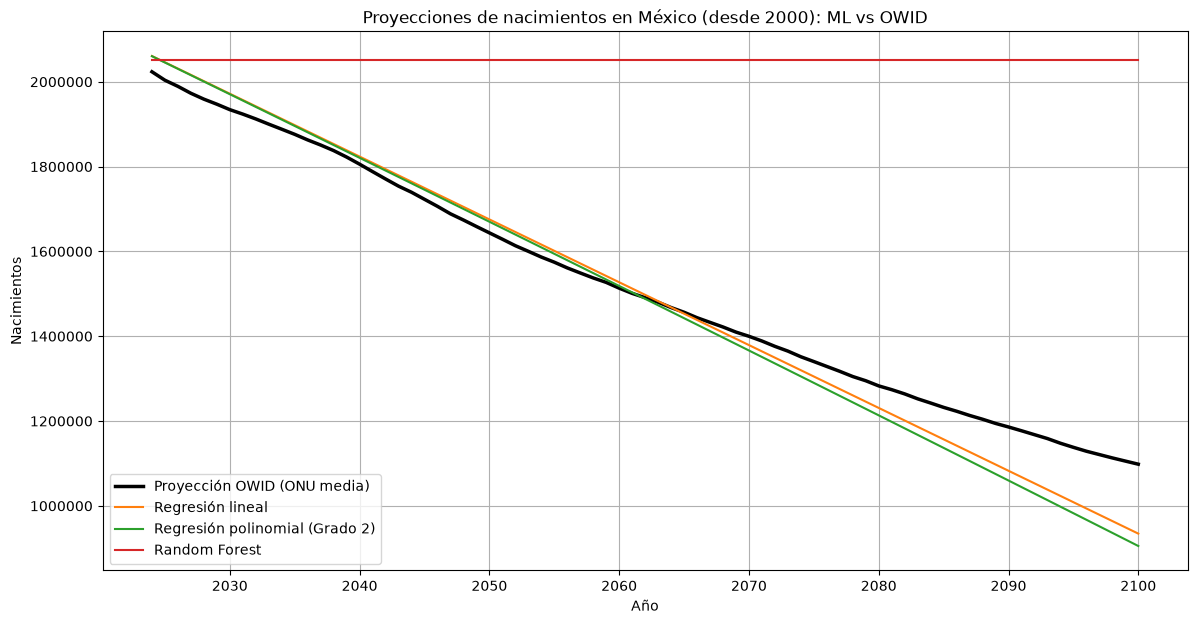

In [24]:
# Comparación con proyecciones de OWID para Nacimientos en México (desde 2000)
plt.figure(figsize=(14, 7))
plt.plot(df_mexico_proyectado["Year"], df_mexico_proyectado["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU media)")
plt.plot(anios_futuros.flatten(), pred_lr_mex_b_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_b_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_b_fut, color="tab:red", label="Random Forest")
plt.title("Proyecciones de nacimientos en México (desde 2000): ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


### 2.3 Modelos para Defunciones en México a partir de 2000 (RL, RP, RF)

In [25]:
y_mex_deaths = df_mexico_historico["deaths"]

# 1. Regresión Lineal
lr_mex_deaths = LinearRegression().fit(X_mex, y_mex_deaths)
pred_lr_mex_d_hist = lr_mex_deaths.predict(X_mex)
pred_lr_mex_d_fut = lr_mex_deaths.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
pr_mex_deaths = LinearRegression().fit(X_mex_poly, y_mex_deaths)
pred_pr_mex_d_hist = pr_mex_deaths.predict(X_mex_poly)
pred_pr_mex_d_fut = pr_mex_deaths.predict(X_mex_futuro_poly)

# 3. Random Forest Regressor
rf_mex_deaths = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_mex, y_mex_deaths)
pred_rf_mex_d_hist = rf_mex_deaths.predict(X_mex)
pred_rf_mex_d_fut = rf_mex_deaths.predict(X_futuro)


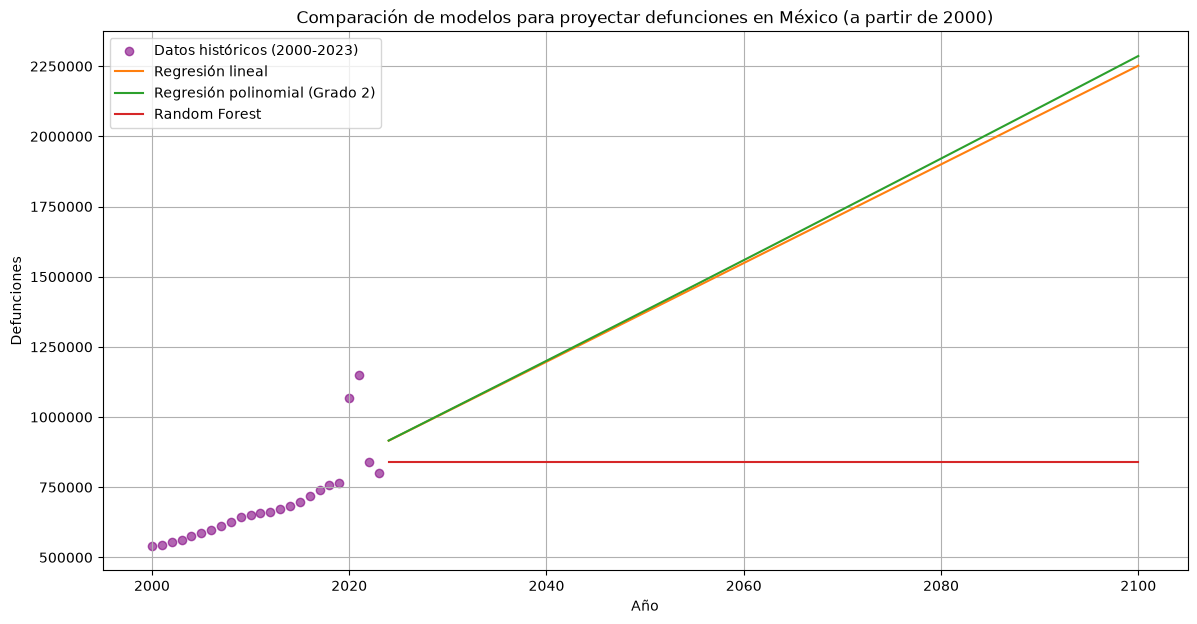

In [26]:
# Comparación conjunta de los tres modelos para Defunciones en México (desde 2000)
plt.figure(figsize=(14, 7))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["deaths"], label="Datos históricos (2000-2023)", alpha=0.6, color="purple")
plt.plot(anios_futuros.flatten(), pred_lr_mex_d_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_d_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_d_fut, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar defunciones en México (a partir de 2000)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


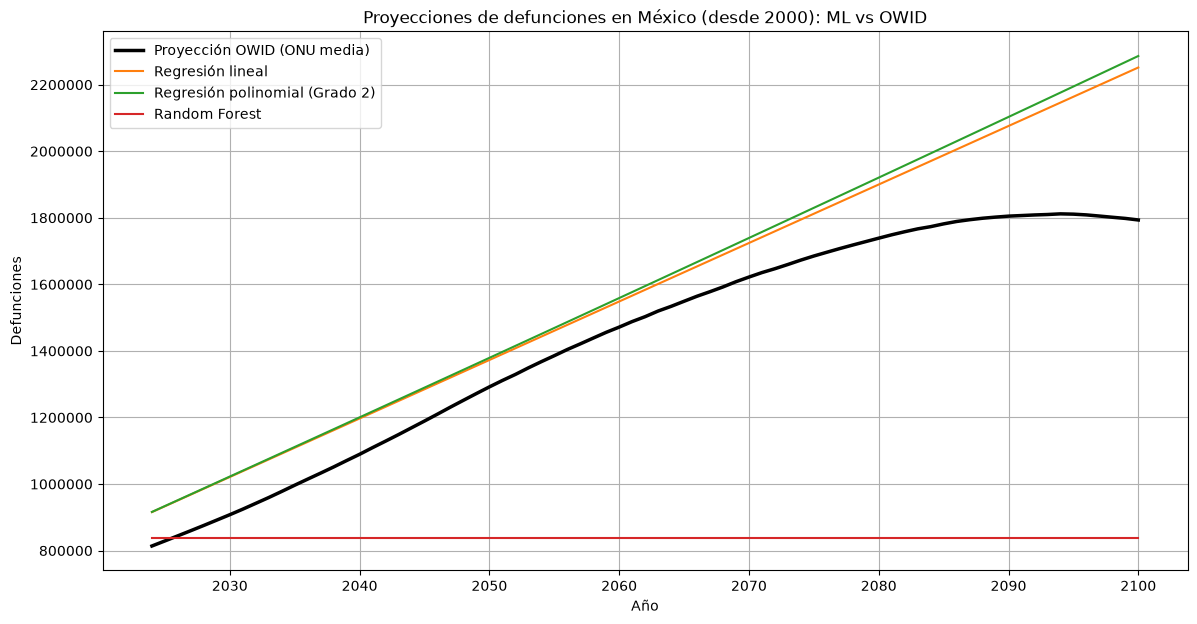

In [27]:
# Comparación con proyecciones de OWID para Defunciones en México (desde 2000)
plt.figure(figsize=(14, 7))
plt.plot(df_mexico_proyectado["Year"], df_mexico_proyectado["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU media)")
plt.plot(anios_futuros.flatten(), pred_lr_mex_d_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_d_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_d_fut, color="tab:red", label="Random Forest")
plt.title("Proyecciones de defunciones en México (desde 2000): ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


### 2.4 Resumen numérico de proyecciones para México (desde 2000)

In [28]:
print("MÉXICO (DESDE 2000) - Proyección de Nacimientos:")
display(construir_tabla_resumen(df_mexico_proyectado, "births", pred_lr_mex_b_fut, pred_pr_mex_b_fut, pred_rf_mex_b_fut).style.format("{:,.0f}"))

print("\nMÉXICO (DESDE 2000) - Proyección de Defunciones:")
display(construir_tabla_resumen(df_mexico_proyectado, "deaths", pred_lr_mex_d_fut, pred_pr_mex_d_fut, pred_rf_mex_d_fut).style.format("{:,.0f}"))


MÉXICO (DESDE 2000) - Proyección de Nacimientos:


,OWID (ONU),Regresión Lineal,Regresión Polinomial,Random Forest
Año,,,,
2030,"1,934,285","1,971,876","1,970,689","2,051,955"
2050,"1,643,767","1,675,481","1,669,982","2,051,955"
2075,"1,340,246","1,304,988","1,289,953","2,051,955"
2100,"1,098,210","934,494","905,317","2,051,955"



MÉXICO (DESDE 2000) - Proyección de Defunciones:


,OWID (ONU),Regresión Lineal,Regresión Polinomial,Random Forest
Año,,,,
2030,"907,843","1,021,129","1,022,528","838,793"
2050,"1,291,889","1,372,705","1,379,209","838,793"
2075,"1,685,181","1,812,175","1,829,978","838,793"
2100,"1,793,462","2,251,646","2,286,211","838,793"
